# M1~M3 신용평가 모델링 — XGBoost

로지스틱 / LightGBM 과 동일 조건으로 맞춰 결과를 나란히 비교할 수 있게 한다.

- `StratifiedKFold` 5-fold, `random_state=42`
- OOF(out-of-fold) 예측으로 AUC 산출
- DeLong 검정으로 ΔAUC 유의성 판정

**모델 정의**

| 모델 | X | 역할 |
|---|---|---|
| M1 | A 금융 | 베이스라인 |
| M2 | B 비금융 | 참고치 |
| M3 | A+B | **RQ1** — 비금융을 더하면 예측력이 오르는가 |

**입력** — `model_A_financial_final.csv`, `model_B_nonfinancial_final.csv`

**출력** — `results_xgb.csv` / `delong_xgb.csv` / `oof_xgb.csv` / `importance_xgb_M3.csv`

실행 시간은 Colab 기준 약 5분.

## 0. 설정

In [5]:
!pip install xgboost -q
import warnings, time, gc
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score
from scipy import stats
import xgboost as xgb
warnings.filterwarnings("ignore")

from google.colab import drive
drive.mount('/content/drive')

SRC = '/content/drive/MyDrive/BOOSTMAP/데이터/완료/재계산'
OUT = '/content/drive/MyDrive/BOOSTMAP/데이터/완료/모델링'
import os; os.makedirs(OUT, exist_ok=True)

FILE_A = f'{SRC}/model_A_financial_final.csv'
FILE_B = f'{SRC}/model_B_nonfinancial_final.csv'

SEED, N_FOLDS = 42, 5
ID, TARGET = 'SK_ID_CURR', 'TARGET'
EARLY_STOP = 80

print('xgboost', xgb.__version__)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
xgboost 3.3.0


## 1. 데이터 로드

`AGE_BAND` 는 EDA 전용 문자열 파생변수라 모델에서 제외한다.

In [6]:
A = pd.read_csv(FILE_A)
B = pd.read_csv(FILE_B)
if 'AGE_BAND' in B.columns:
    B = B.drop(columns=['AGE_BAND'])

assert set(A[ID]) == set(B[ID]), 'A/B SK_ID_CURR 불일치'
m = A.merge(B.drop(columns=[TARGET]), on=ID, how='inner')
y = m[TARGET].astype(int).values

A_cols = [c for c in A.columns if c not in (ID, TARGET)]
B_cols = [c for c in B.columns if c not in (ID, TARGET)]
del A, B; gc.collect()

SPW = (y == 0).sum() / (y == 1).sum()

print(f'행 {len(m):,} | 결측 {m.isna().sum().sum()} | 연체율 {y.mean():.4f}')
print(f'A(금융) {len(A_cols)}  B(비금융) {len(B_cols)}  M3(A+B) {len(A_cols)+len(B_cols)}')
print(f'scale_pos_weight = {SPW:.2f}')

SPECS = {'M1': A_cols, 'M2': B_cols, 'M3': A_cols + B_cols}
FOLDS = list(StratifiedKFold(N_FOLDS, shuffle=True,
                             random_state=SEED).split(m, y))

행 307,511 | 결측 0 | 연체율 0.0807
A(금융) 18  B(비금융) 31  M3(A+B) 49
scale_pos_weight = 11.39


## 2. 하이퍼파라미터

LightGBM 과의 대응 관계.

| 개념 | LightGBM | XGBoost |
|---|---|---|
| 트리 크기 | `num_leaves=31` | `max_depth=5` (2⁵ = 32) |
| 리프 최소표본 | `min_child_samples=100` | `min_child_weight=100` |
| 불균형 보정 | `scale_pos_weight` | `scale_pos_weight` |

나머지(`n_estimators`, `learning_rate`, `colsample_bytree`, `subsample`,
`reg_lambda`)는 이름과 값이 모두 동일하다.

In [7]:
PARAMS = dict(
    n_estimators=1000,
    learning_rate=0.02,
    max_depth=5,
    colsample_bytree=0.8,
    subsample=0.9,
    reg_lambda=1.0,
    min_child_weight=100,
    scale_pos_weight=SPW,
    tree_method='hist',
    eval_metric='auc',
    early_stopping_rounds=EARLY_STOP,
    n_jobs=-1,
    verbosity=0,
    random_state=SEED,
)
PARAMS

{'n_estimators': 1000,
 'learning_rate': 0.02,
 'max_depth': 5,
 'colsample_bytree': 0.8,
 'subsample': 0.9,
 'reg_lambda': 1.0,
 'min_child_weight': 100,
 'scale_pos_weight': np.float64(11.387150050352467),
 'tree_method': 'hist',
 'eval_metric': 'auc',
 'early_stopping_rounds': 80,
 'n_jobs': -1,
 'verbosity': 0,
 'random_state': 42}

## 3. 교차검증

**검증 fold 누수 차단** — `eval_set` 에 검증 fold 를 넣으면 트리 개수를
그 fold 를 보고 정하게 되어 OOF 예측이 낙관적으로 나온다.
train 을 다시 90:10 으로 쪼개 early stopping 전용 셋을 만든다.

`float32` 변환은 메모리를 절반으로 줄인다. 30만 행 × 49변수에서 필요하다.

In [8]:
def cv(cols):
    X = m[cols].replace([np.inf, -np.inf], np.nan).astype('float32')
    oof = np.zeros(len(y))
    iters, imps = [], []

    for k, (tr, va) in enumerate(FOLDS, 1):
        # early stopping 전용 셋 (train 의 10%)
        itr, ies = train_test_split(tr, test_size=0.1,
                                    random_state=SEED + k, stratify=y[tr])
        mdl = xgb.XGBClassifier(**PARAMS)
        mdl.fit(X.iloc[itr], y[itr],
                eval_set=[(X.iloc[ies], y[ies])], verbose=False)

        iters.append(mdl.best_iteration)
        oof[va] = mdl.predict_proba(X.iloc[va])[:, 1]
        imps.append(pd.Series(mdl.feature_importances_, index=cols))
        del mdl; gc.collect()

    imp = pd.concat(imps, axis=1).mean(axis=1)
    return oof, roc_auc_score(y, oof), int(np.mean(iters)), imp

## 4. DeLong 검정

같은 표본에서 나온 두 AUC 를 비교하는 검정. 상관된 AUC 를 다루므로
일반 t검정을 쓰면 안 된다.

`H0 : AUC(M3) = AUC(M1)`

In [9]:
def _midrank(x):
    J = np.argsort(x); Z = x[J]; N = len(x); T = np.zeros(N); i = 0
    while i < N:
        j = i
        while j < N and Z[j] == Z[i]:
            j += 1
        T[i:j] = 0.5 * (i + j - 1) + 1.0
        i = j
    o = np.empty(N); o[J] = T
    return o


def delong(y, s_full, s_reduced):
    """반환: ΔAUC, z, p(양측)"""
    y = np.asarray(y, float)
    order = (-y).argsort(kind='mergesort')
    mpos = int(y.sum())
    p = np.vstack((np.asarray(s_full)[order], np.asarray(s_reduced)[order]))
    n = p.shape[1] - mpos
    tx = np.vstack([_midrank(p[r, :mpos]) for r in range(2)])
    ty = np.vstack([_midrank(p[r, mpos:]) for r in range(2)])
    tz = np.vstack([_midrank(p[r, :]) for r in range(2)])
    aucs = tz[:, :mpos].sum(1) / mpos / n - (mpos + 1.0) / 2.0 / n
    cov = (np.cov((tz[:, :mpos] - tx) / n) / mpos
           + np.cov(1.0 - (tz[:, mpos:] - ty) / mpos) / n)
    var = float((np.array([[1., -1.]]) @ np.atleast_2d(cov)
                 @ np.array([[1.], [-1.]])).item())
    d = float(aucs[0] - aucs[1])
    if var <= 0:
        return d, 0.0, 1.0
    z = d / np.sqrt(var)
    return d, z, float(2 * (1 - stats.norm.cdf(abs(z))))

## 5. 학습

여기가 가장 오래 걸린다. 모델별로 진행 상황이 출력된다.

In [10]:
oofs, rows, imps = {}, [], {}
for name, cols in SPECS.items():
    t0 = time.time()
    o, auc, it, imp = cv(cols)
    oofs[name], imps[name] = o, imp
    rows.append({'모델': name, 'X구성': {'M1': 'A', 'M2': 'B', 'M3': 'A+B'}[name],
                 '변수수': len(cols), 'OOF_AUC': round(auc, 5),
                 '평균트리': it, '초': round(time.time() - t0)})
    print(f'  {name} n={len(cols):3d} AUC={auc:.5f} trees={it} '
          f'({time.time()-t0:.0f}s)', flush=True)

res = pd.DataFrame(rows)
display(res.style.hide(axis='index')
           .background_gradient(subset=['OOF_AUC'], cmap='Blues')
           .format({'OOF_AUC': '{:.5f}'}))

  M1 n= 18 AUC=0.69786 trees=925 (118s)
  M2 n= 31 AUC=0.62528 trees=320 (49s)
  M3 n= 49 AUC=0.71083 trees=983 (155s)


모델,X구성,변수수,OOF_AUC,평균트리,초
M1,A,18,0.69786,925,118
M2,B,31,0.62528,320,49
M3,A+B,49,0.71083,983,155


## 6. RQ1 검정

`H0 : AUC(M3) = AUC(M1)`

In [11]:
dl_rows = []
for tag, a, b in [('RQ1: M3 vs M1', 'M3', 'M1'),
                  ('(참고) M3 vs M2', 'M3', 'M2'),
                  ('(참고) M2 vs M1', 'M2', 'M1')]:
    d, z, p = delong(y, oofs[a], oofs[b])
    dl_rows.append({'비교': tag, 'ΔAUC(%p)': round(d * 100, 3), 'z': round(z, 1),
                    'p': f'{p:.2e}', '통계유의': p < 0.05,
                    '실무유의(≥1%p)': d >= 0.01})

dl = pd.DataFrame(dl_rows)
display(dl.style.hide(axis='index')
          .background_gradient(subset=['ΔAUC(%p)'], cmap='RdYlGn', vmin=-8, vmax=8))

비교,ΔAUC(%p),z,p,통계유의,실무유의(≥1%p)
RQ1: M3 vs M1,1.297000,14.800000,0.00e+00,True,True
(참고) M3 vs M2,8.554000,51.800000,0.00e+00,True,True
(참고) M2 vs M1,-7.257000,-33.000000,0.00e+00,True,False


## 7. 변수 중요도

트리의 중요도는 **크기만 있고 부호가 없다.**
"학력이 높을수록 연체 확률이 낮다" 같은 방향 해석은 로지스틱 계수에서 가져와야 한다.

In [12]:
grp = {c: ('A_금융' if c in A_cols else 'B_비금융') for c in A_cols + B_cols}
top = imps['M3'].sort_values(ascending=False)

t20 = top.head(20).to_frame('중요도')
t20.insert(0, '군', [grp[c] for c in t20.index])
t20.insert(0, '순위', range(1, len(t20) + 1))

gsum = top.groupby([grp[c] for c in top.index]).agg(['sum', 'count'])
gsum.columns = ['중요도합', '변수수']
gsum['변수당'] = (gsum['중요도합'] / gsum['변수수']).round(4)
gsum['비중(%)'] = (gsum['중요도합'] / top.sum() * 100).round(1)

print('■ 군별 중요도')
display(gsum)
print('■ 상위 20개 변수')
display(t20.style.hide(axis='index')
           .background_gradient(subset=['중요도'], cmap='Oranges')
           .format({'중요도': '{:.4f}'}))

■ 군별 중요도


,중요도합,변수수,변수당,비중(%)
A_금융,0.474174,18,0.0263,47.400002
B_비금융,0.525826,31,0.0170,52.599998


■ 상위 20개 변수


순위,군,중요도
1,B_비금융,0.0806
2,A_금융,0.0781
3,A_금융,0.0511
4,A_금융,0.0407
5,B_비금융,0.0369
6,B_비금융,0.0353
7,A_금융,0.0338
8,A_금융,0.0331
9,A_금융,0.0323
10,B_비금융,0.0303


## 8. 결과 시각화

축 라벨은 한글 폰트 설치 없이 렌더되도록 영문으로 둔다.

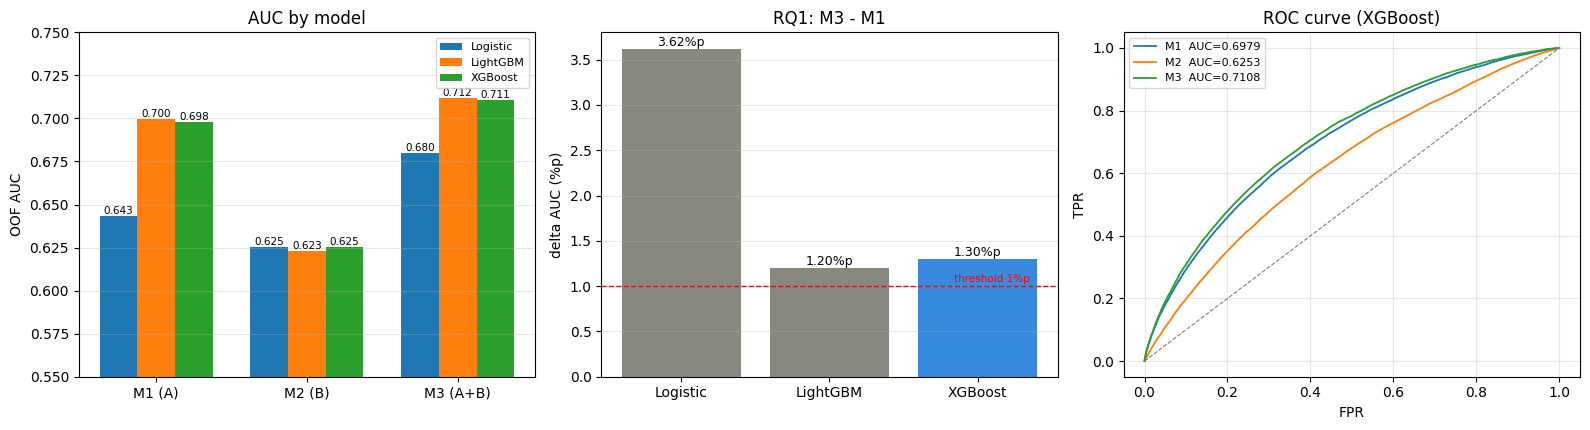

In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

REF = {'Logistic': {'M1': 0.6435, 'M2': 0.6254, 'M3': 0.6797},
       'LightGBM': {'M1': 0.6996, 'M2': 0.6228, 'M3': 0.7116}}
auc = dict(zip(res['모델'], res['OOF_AUC']))
ALL = {**REF, 'XGBoost': auc}

fig, ax = plt.subplots(1, 3, figsize=(16, 4.4))

# (1) 알고리즘 x 모델 AUC
w, xs = 0.25, np.arange(3)
for i, (name, d) in enumerate(ALL.items()):
    v = [d['M1'], d['M2'], d['M3']]
    b = ax[0].bar(xs + (i - 1) * w, v, w, label=name)
    ax[0].bar_label(b, fmt='%.3f', fontsize=7.5)
ax[0].set_xticks(xs); ax[0].set_xticklabels(['M1 (A)', 'M2 (B)', 'M3 (A+B)'])
ax[0].set_ylim(0.55, 0.75); ax[0].set_ylabel('OOF AUC')
ax[0].set_title('AUC by model'); ax[0].legend(fontsize=8); ax[0].grid(axis='y', alpha=.3)

# (2) RQ1 delta AUC
names = list(ALL); deltas = [(ALL[n]['M3'] - ALL[n]['M1']) * 100 for n in names]
b = ax[1].bar(names, deltas, color=['#888780', '#888780', '#378ADD'])
ax[1].bar_label(b, fmt='%.2f%%p', fontsize=9)
ax[1].axhline(1, ls='--', c='red', lw=1)
ax[1].text(2.35, 1.05, 'threshold 1%p', color='red', fontsize=7.5, ha='right')
ax[1].set_ylabel('delta AUC (%p)'); ax[1].set_title('RQ1: M3 - M1')
ax[1].grid(axis='y', alpha=.3)

# (3) ROC (XGBoost)
for name in ['M1', 'M2', 'M3']:
    fpr, tpr, _ = roc_curve(y, oofs[name])
    ax[2].plot(fpr, tpr, lw=1.3, label=f'{name}  AUC={auc[name]:.4f}')
ax[2].plot([0, 1], [0, 1], ls='--', c='gray', lw=.8)
ax[2].set_xlabel('FPR'); ax[2].set_ylabel('TPR')
ax[2].set_title('ROC curve (XGBoost)'); ax[2].legend(fontsize=8); ax[2].grid(alpha=.3)

plt.tight_layout(); plt.show()

## 9. 최종 결과

In [14]:
cmp_tbl = pd.DataFrame(ALL).reindex(['M1', 'M2', 'M3'])
cmp_tbl.index = ['M1 (A, %d)' % len(A_cols), 'M2 (B, %d)' % len(B_cols),
                 'M3 (A+B, %d)' % (len(A_cols) + len(B_cols))]
cmp_tbl.loc['RQ1 ΔAUC(%p)'] = [round((ALL[n]['M3'] - ALL[n]['M1']) * 100, 2)
                               for n in ALL]

print('■ 알고리즘 비교 (5-fold OOF AUC · seed 42 · EXT 제외)')
display(cmp_tbl.style.format('{:.4f}', subset=(cmp_tbl.index[:3], slice(None)))
                     .format('{:+.2f}', subset=(cmp_tbl.index[3:], slice(None)))
                     .background_gradient(cmap='Blues', axis=None,
                                          subset=(cmp_tbl.index[:3], slice(None))))

rq = dl.iloc[0]
print(f'''
■ RQ1 — 비금융(B)이 금융(A)에 예측력을 더하는가?
   XGBoost   ΔAUC {rq["ΔAUC(%p)"]:+.2f}%p   DeLong p = {rq["p"]}
   통계유의 {rq["통계유의"]}   실무유의(≥1%p) {rq["실무유의(≥1%p)"]}
   → 세 알고리즘 모두 같은 방향, 모두 유의

■ 해석
   · M2 < M1 : 비금융은 금융의 대체재가 아니라 보완재
   · 트리가 로지스틱보다 M1 을 크게 끌어올림
     EDA 의 비단조 관계(주요 변수 9개 중 7개)를 트리가 활용
     베이스라인이 높아져 ΔAUC 는 오히려 축소
   · 중요도 비중  A_금융 {gsum.loc["A_금융", "비중(%)"]:.1f}%  /  B_비금융 {gsum.loc["B_비금융", "비중(%)"]:.1f}%

■ 다음 단계
   M4(A+B+C) · M5(A+C) 추가 → RQ2 (M5 vs M3) 검증''')

■ 알고리즘 비교 (5-fold OOF AUC · seed 42 · EXT 제외)


,Logistic,LightGBM,XGBoost
"M1 (A, 18)",0.6435,0.6996,0.6979
"M2 (B, 31)",0.6254,0.6228,0.6253
"M3 (A+B, 49)",0.6797,0.7116,0.7108
RQ1 ΔAUC(%p),+3.62,+1.20,+1.30



■ RQ1 — 비금융(B)이 금융(A)에 예측력을 더하는가?
   XGBoost   ΔAUC +1.30%p   DeLong p = 0.00e+00
   통계유의 True   실무유의(≥1%p) True
   → 세 알고리즘 모두 같은 방향, 모두 유의

■ 해석
   · M2 < M1 : 비금융은 금융의 대체재가 아니라 보완재
   · 트리가 로지스틱보다 M1 을 크게 끌어올림
     EDA 의 비단조 관계(주요 변수 9개 중 7개)를 트리가 활용
     베이스라인이 높아져 ΔAUC 는 오히려 축소
   · 중요도 비중  A_금융 47.4%  /  B_비금융 52.6%

■ 다음 단계
   M4(A+B+C) · M5(A+C) 추가 → RQ2 (M5 vs M3) 검증


### M4 · M5 추가 방법

C군 파일을 읽어 `SPECS` 에 두 줄만 추가하면 RQ2 도 검증할 수 있다.

```python
C = pd.read_csv(f'{SRC}/model_C_nonfinancial_new_final.csv')
m = m.merge(C.drop(columns=[TARGET]), on=ID, how='inner')
C_cols = [c for c in C.columns if c not in (ID, TARGET)]

SPECS = {'M1': A_cols, 'M2': B_cols, 'M3': A_cols + B_cols,
         'M4': A_cols + B_cols + C_cols, 'M5': A_cols + C_cols}
```

트리 계열은 C군을 그대로 넣어도 되지만, **로지스틱은 M4·M5 에서
학력·주거 기준범주 2개를 제거**해야 한다. 원핫 행 합이 항상 1이라
설계행렬이 특이행렬이 되기 때문이다.

### 결과를 파일로 남기려면

필요할 때만 실행한다.

```python
res.to_csv(f'{OUT}/results_xgb.csv', index=False, encoding='utf-8-sig')
dl.to_csv(f'{OUT}/delong_xgb.csv', index=False, encoding='utf-8-sig')
pd.DataFrame({'SK_ID_CURR': m[ID].values, 'TARGET': y,
              **{f'oof_{k}': v for k, v in oofs.items()}}).to_csv(
    f'{OUT}/oof_xgb.csv', index=False)
```

`oof_xgb.csv` 는 로지스틱·LightGBM 의 OOF 와 붙여
알고리즘 간 DeLong 검정을 할 때 쓴다. fold 분할이 동일해야 성립한다.